# Prior analysis
_Is NN better than RL just because it learns shapes?_

In [1]:
import torch
import numpy as np

from src.data_helpers import rectangle_image, circle_image, line_grid_image, blurring_func
from src.testing_helpers import prior_testing
from src.NNdeconvolution import DeconvolutionUNet_Baseline
from src.data_helpers import GeometricDataGenerator, white_noise_image, structured_texture_image

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Load best NN model
model = DeconvolutionUNet_Baseline()
state_dict = torch.load('nn_training/models/nn_baseline_model.pth', map_location=torch.device(device))
model.load_state_dict(state_dict)
model.eval()

DeconvolutionUNet_Baseline(
  (enc0): DoubleConvxReLU_NoNorm(
    (convxrelu2): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.1, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.1, inplace=True)
    )
  )
  (enc1): DoubleConvxReLU_NoNorm(
    (convxrelu2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.1, inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.1, inplace=True)
    )
  )
  (enc2): DoubleConvxReLU_NoNorm(
    (convxrelu2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.1, inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(neg

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


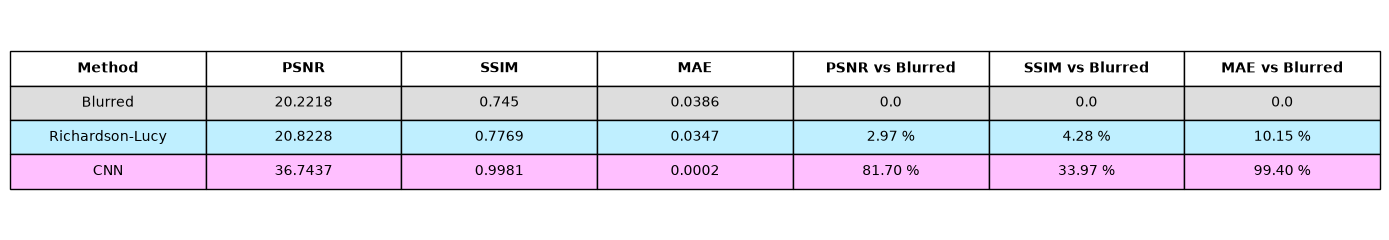

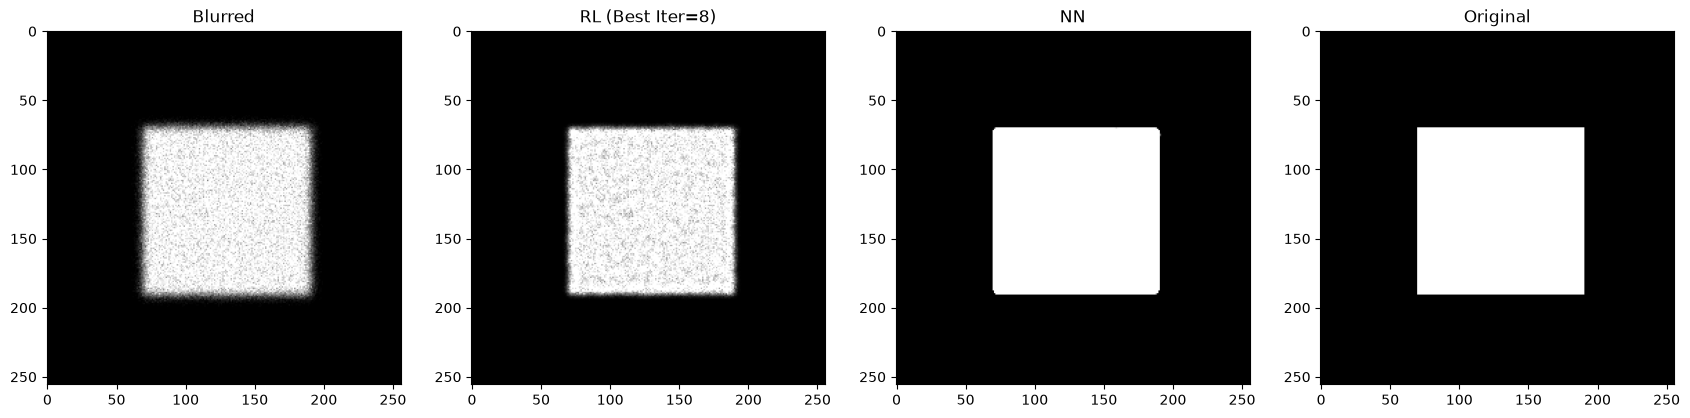

In [4]:
# 1 Rectangle – easiest (straight edges)
rectangle_img_target = rectangle_image()
rectangle_img_input, rectangle_img_psf = blurring_func(rectangle_img_target)
rectangle_df = prior_testing(
    target=rectangle_img_target,
    input_img=rectangle_img_input,
    psf=rectangle_img_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_rectangle"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


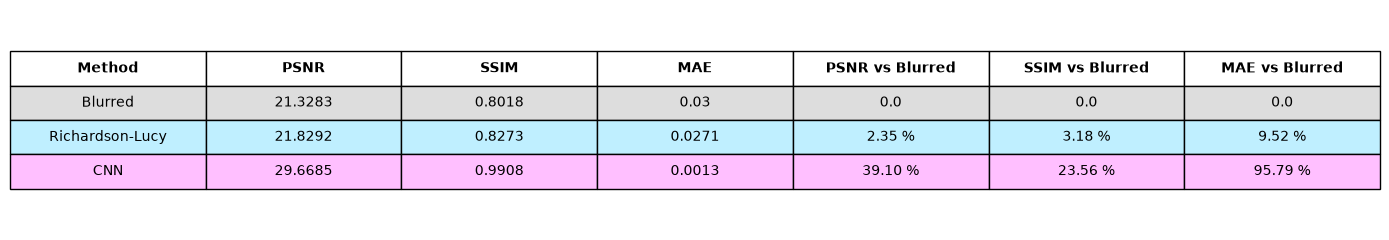

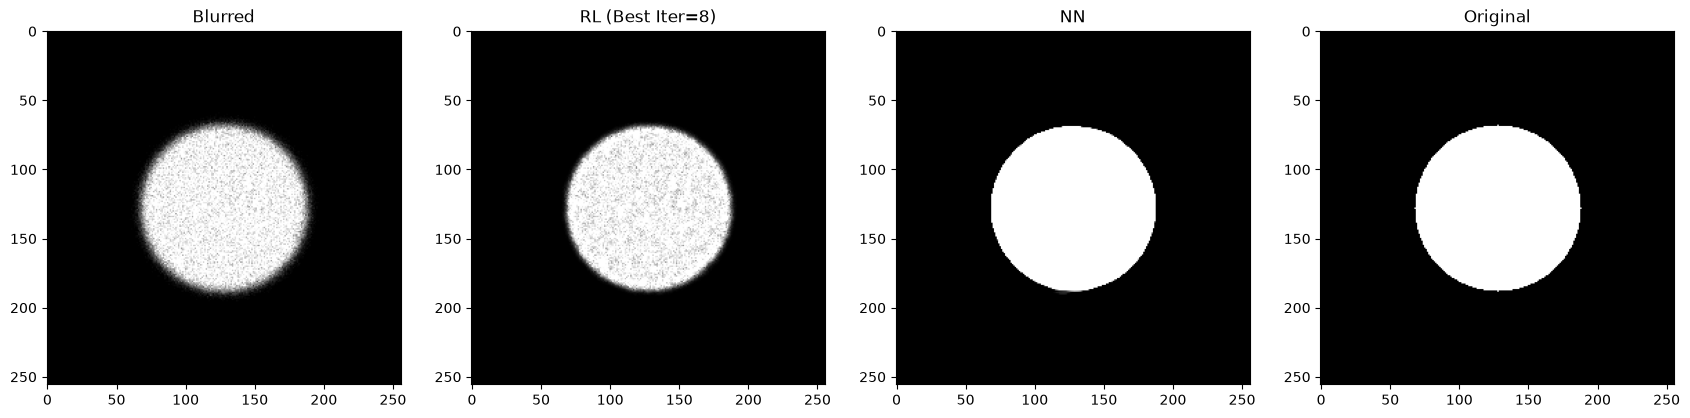

In [5]:
# 1 Circle – curved edges
circle_img_target = circle_image()
circle_img_input, circle_img_psf = blurring_func(circle_img_target)
circle_df = prior_testing(
    target=circle_img_target,
    input_img=circle_img_input,
    psf=circle_img_psf,
    model=model, device=device,
    path="prior_testing",
    save_name="comp_circle"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


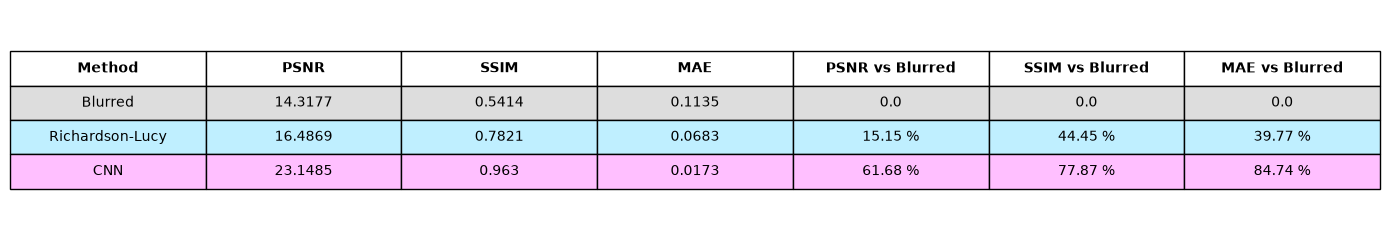

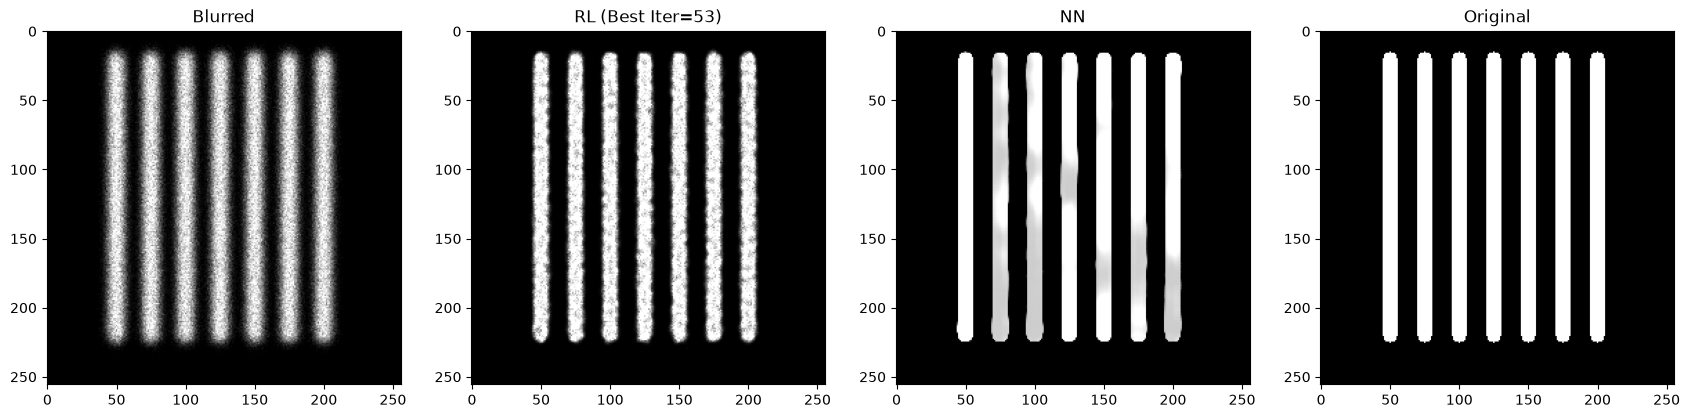

In [6]:
# Bars – resolution limit and repeating structures
line_grid_img_target = line_grid_image()
line_grid_img_input, line_grid_img_psf = blurring_func(line_grid_img_target)
line_grid_df = prior_testing(
    target=line_grid_img_target,
    input_img=line_grid_img_input,
    psf=line_grid_img_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_bars"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


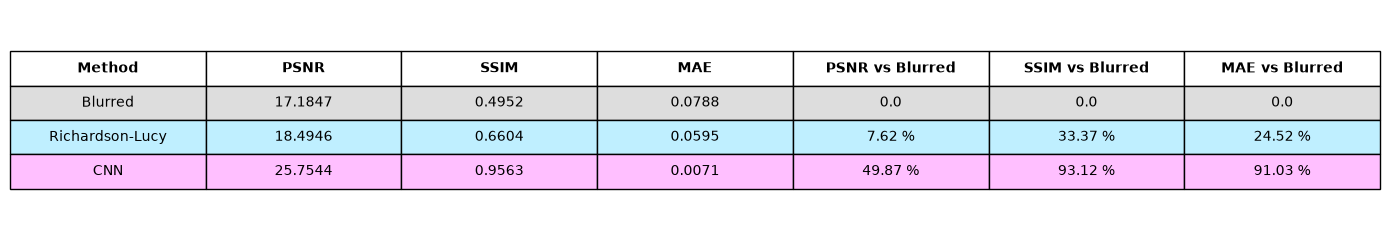

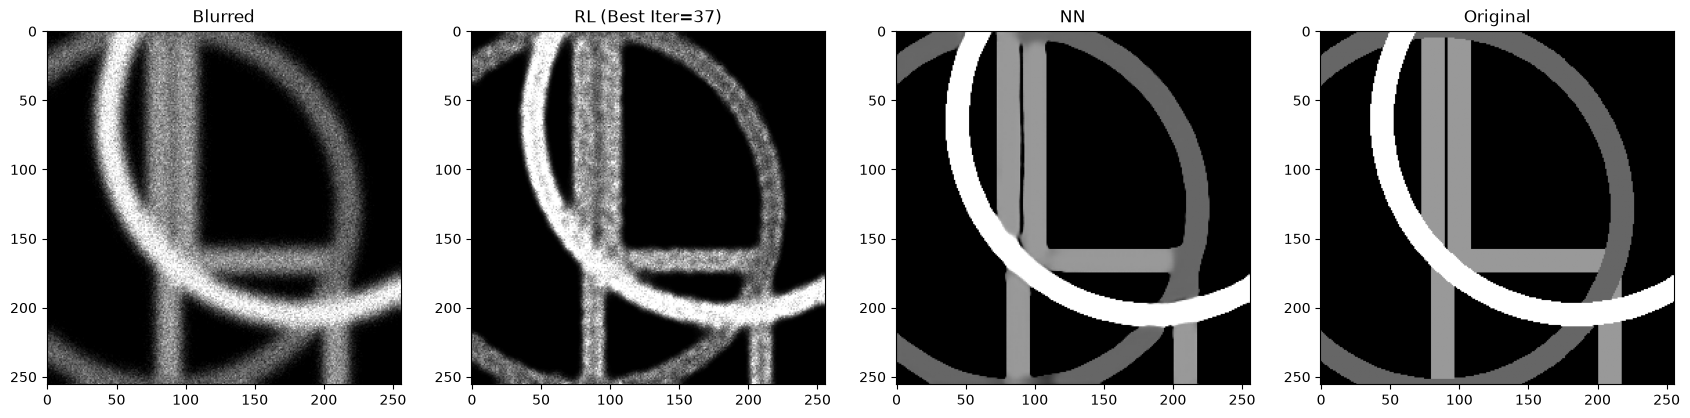

In [7]:
# Overlapped shapes – dataset-like images
test_dataset = GeometricDataGenerator(
    num_samples=1,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=False,
    data_loading=False
)
overlap_img_input, overlap_img_target, overlap_img_psf, *_ = test_dataset[0]
overlap_img_input = overlap_img_input.squeeze().numpy().astype(np.float32)
overlap_img_target = overlap_img_target.squeeze().numpy().astype(np.float32)

overlap_df = prior_testing(
    target=overlap_img_target,
    input_img=overlap_img_input,
    psf=overlap_img_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_overlapped_blur_poisson"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


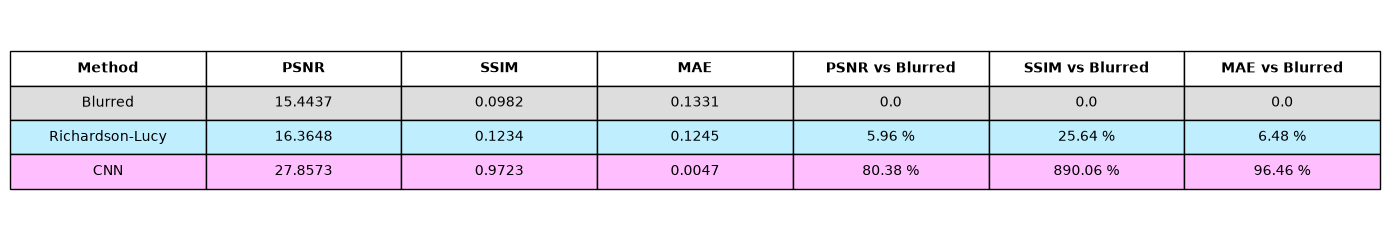

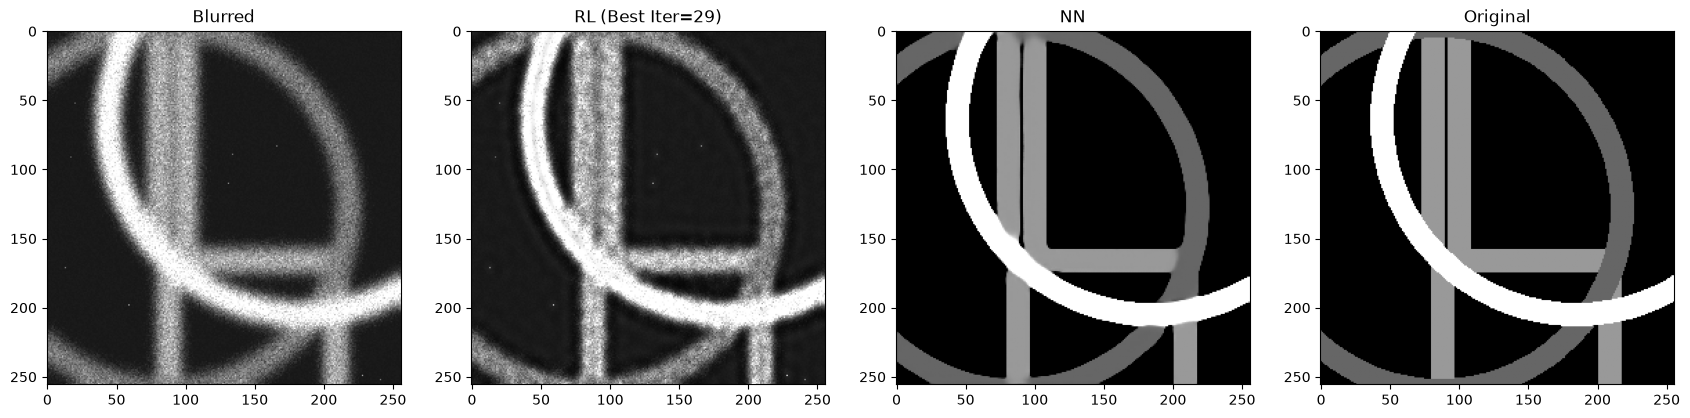

In [8]:
test_dataset = GeometricDataGenerator(
    num_samples=1,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=True,
    data_loading=False
)
full_img_input, full_img_target, full_img_psf, *_ = test_dataset[0]
full_img_input = full_img_input.squeeze().numpy().astype(np.float32)
full_img_target = full_img_target.squeeze().numpy().astype(np.float32)

full_df = prior_testing(
    target=full_img_target,
    input_img=full_img_input,
    psf=full_img_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_overlapped_full_detector"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


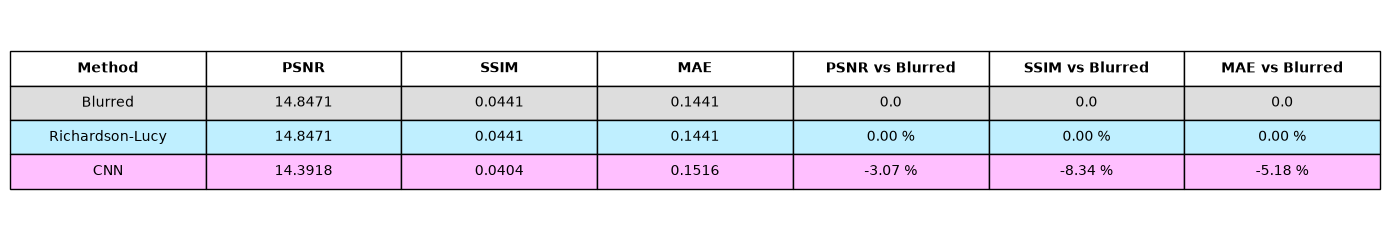

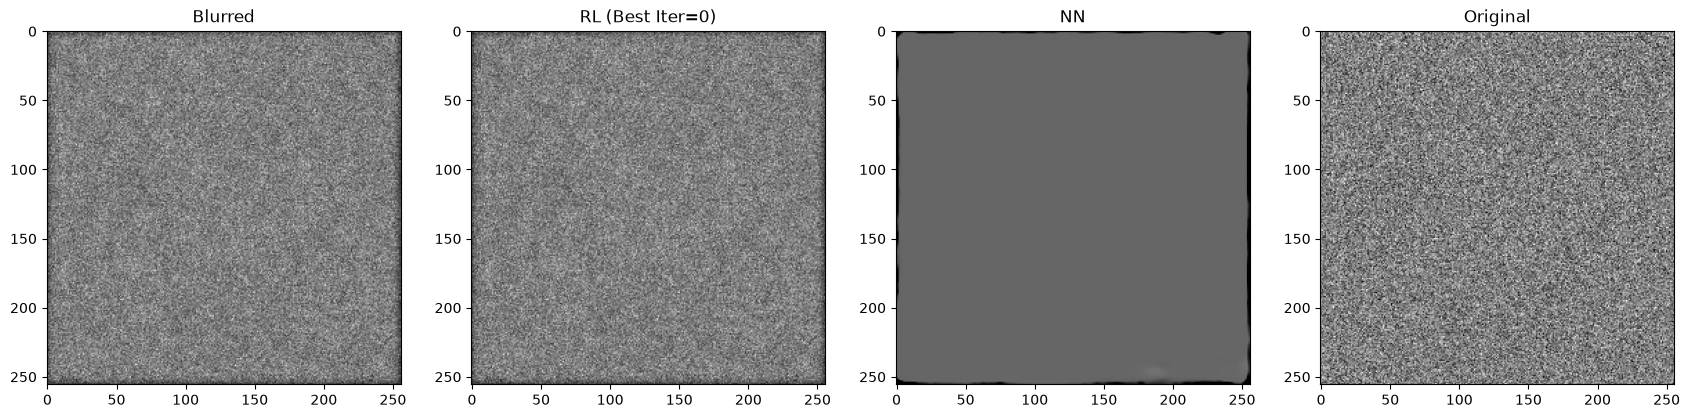

In [9]:
white_noise_target = white_noise_image()
white_noise_img_input, white_noise_img_psf = blurring_func(white_noise_target, sigma_x=3.0, sigma_y=3.0, photon_flux=50)

white_noise_df = prior_testing(
    target=white_noise_target,
    input_img=white_noise_img_input,
    psf=white_noise_img_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_white_noise"
)

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


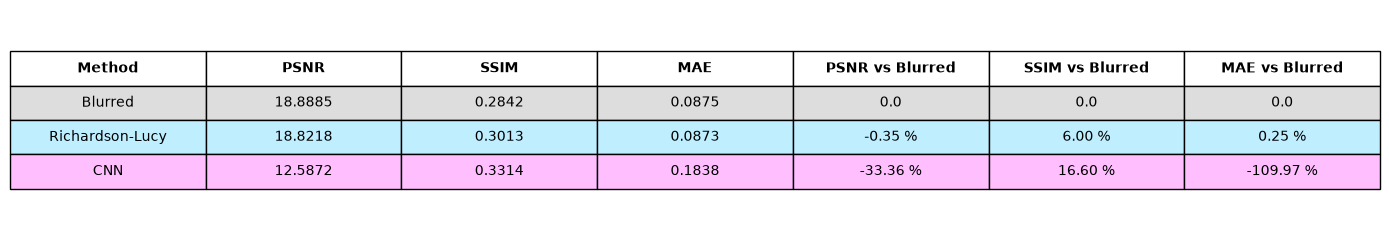

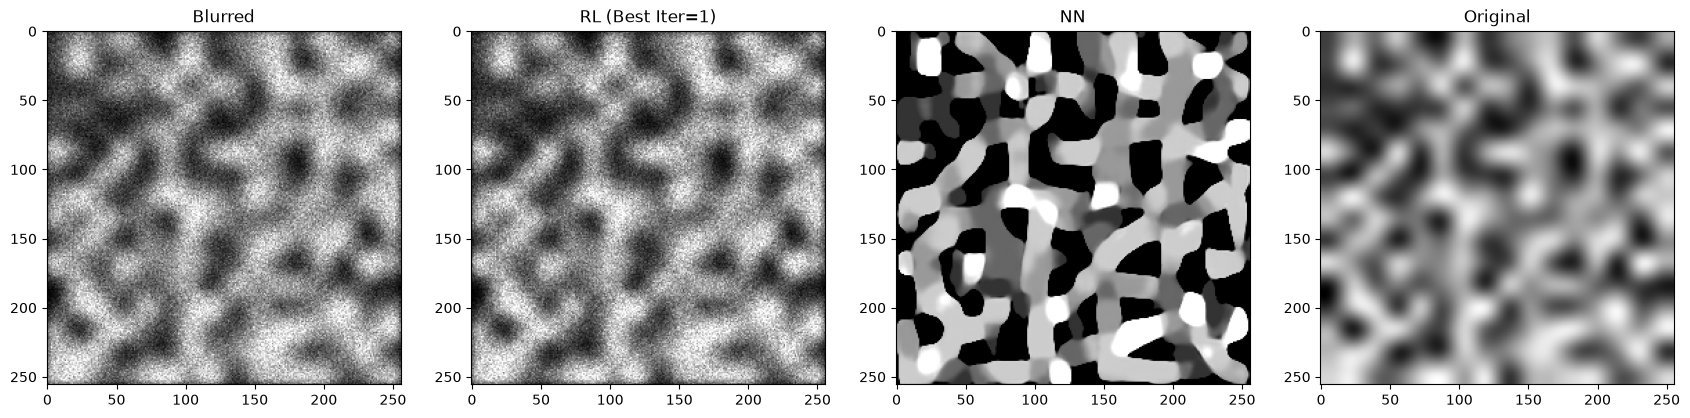

In [10]:
structured_noise_target = structured_texture_image()
structured_noise_img_input, structured_noise_psf = blurring_func(structured_noise_target, sigma_x=3.0, sigma_y=3.0, photon_flux=50)

structured_noise_df = prior_testing(
    target=structured_noise_target,
    input_img=structured_noise_img_input,
    psf=structured_noise_psf,
    model=model,
    device=device,
    path="prior_testing",
    save_name="comp_struct_noise"
)